# 0. Imports & Configs

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
%cd "/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/final-project/+ ghost"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/final-project/+ ghost


In [ ]:
# All imports
import torch
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from collections import Counter
import matplotlib.pyplot as plt
import os
import timm
import time
import json

import os, sys
# nếu notebook đang chạy trong folder con, thêm parent folder:
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from ghost_module import GhostModule

from sklearn.metrics import precision_score, recall_score, confusion_matrix, classification_report
import seaborn as sns
import numpy as np

# Check CUDA availability
print(f"CUDA is available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"cuDNN version: {torch.backends.cudnn.version()}")
print(f"Number of CUDA devices: {torch.cuda.device_count()}")
print(f"Current device: {torch.cuda.current_device()}, Device name: {torch.cuda.get_device_name(0)}")
print(f"Device capability: {torch.cuda.get_device_capability(0)}")
print(f"Device properties: {torch.cuda.get_device_properties(0)}")

CUDA is available: True
CUDA version: 12.8
cuDNN version: 91900
Number of CUDA devices: 1
Current device: 0, Device name: Tesla T4
Device capability: (7, 5)
Device properties: _CudaDeviceProperties(name='Tesla T4', major=7, minor=5, total_memory=14912MB, multi_processor_count=40, uuid=d96770cf-3bb4-073d-2261-584bea5ed66d, pci_bus_id=0, pci_device_id=4, pci_domain_id=0, L2_cache_size=4MB)


In [ ]:
# Configuration: Base folder and paths
BASE_FOLDER = "/content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/"
DATASET_PATH = os.path.join(BASE_FOLDER, "mahmoud-dataset/Images")
MODEL_SAVE_PATH = os.path.join(BASE_FOLDER, "ghost/convnexttiny_v2")
BEST_MODEL_PATH = os.path.join(MODEL_SAVE_PATH, "best.pth")
BEST_HP_PATH = os.path.join(MODEL_SAVE_PATH, "best_hp.json")

os.makedirs(MODEL_SAVE_PATH, exist_ok=True)

print(f"Base folder: {BASE_FOLDER}")
print(f"Dataset path: {DATASET_PATH}")
print(f"Model save path: {MODEL_SAVE_PATH}")

Base folder: /content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/
Dataset path: /content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/mahmoud-dataset/Images
Model save path: /content/drive/MyDrive/Colab-Notebooks/ML4Autism/train/ghost/convnexttiny_v2


In [18]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 100
pos_weight = torch.tensor([0.67], device=device)
criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)
patience = 6
lr = 1e-5
#weight_decay = 1e-4
max_norm = 0.5
args=Args(alpha=0.01)

def update_training_phase(model, optimizer, epoch, base_lr):
    """
    Updated Phasing Logic:
    Phase 1 (0-4): freeze_backbone=True, lr=base_lr
    Phase 2 (5-24): freeze_backbone=False, lr=base_lr
    Phase 3 (25-99): freeze_backbone=False, lr=base_lr * 0.3
    """
    if epoch < 5:
        # Phase 1: Warm-up head
        for param in model.backbone.parameters():
            param.requires_grad = False
        current_lr = base_lr
    elif epoch < 25:
        # Phase 2: Fine-tune all
        for param in model.backbone.parameters():
            param.requires_grad = True
        current_lr = base_lr * 0.1
    else:
        # Phase 3: Convergence
        for param in model.backbone.parameters():
            param.requires_grad = True
        current_lr = base_lr * 0.3

    for param_group in optimizer.param_groups:
        param_group['lr'] = current_lr
    return current_lr

# 1. Load Data

In [ ]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

dataset = datasets.ImageFolder(DATASET_PATH, transform=transform)
targets = [label for _, label in dataset]

# Split 70/30
train_idx, temp_idx = train_test_split(
    range(len(dataset)),
    test_size=0.3,
    stratify=targets,
    random_state=42,
)

# Split 30 to 20/10
temp_targets = [targets[i] for i in temp_idx]
val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.385,
    stratify=temp_targets,
    random_state=42,
)

train_sampler = torch.utils.data.SubsetRandomSampler(train_idx)
val_sampler   = torch.utils.data.SubsetRandomSampler(val_idx)
test_sampler  = torch.utils.data.SubsetRandomSampler(test_idx)

batch_size = 32

train_loader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=train_sampler)
val_loader   = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=val_sampler)
test_loader  = torch.utils.data.DataLoader(dataset, batch_size=batch_size, sampler=test_sampler)

print(f"Train samples: {len(train_idx)}, Val samples: {len(val_idx)}, Test samples: {len(test_idx)}")
print(f"Train batches: {len(train_loader)},  Val batches: {len(val_loader)},   Test batches: {len(test_loader)}")

Train samples: 382, Val samples: 101, Test samples: 64
Train batches: 12,  Val batches: 4,   Test batches: 2


In [ ]:
def count_classes(indices, dataset):
    labels = [dataset.samples[i][1] for i in indices]
    return Counter(labels)

print("Class mapping:", dataset.class_to_idx)
print("Train class count:", count_classes(train_idx, dataset))
print("Val class count:  ", count_classes(val_idx, dataset))
print("Test class count: ", count_classes(test_idx, dataset))

Class mapping: {'ASD': 0, 'non-ASD': 1}
Train class count: Counter({1: 229, 0: 153})
Val class count:   Counter({1: 61, 0: 40})
Test class count:  Counter({1: 38, 0: 26})


# 2. Augment Data

In [ ]:
def augment_pre_fmmix1(images, labels):
    B = images.size(0)
    flip_mask = torch.rand(B, device=images.device) < 0.5
    for i in range(B):
        if flip_mask[i]:
            images[i] = torch.flip(images[i], dims=[2])
    brightness_delta = torch.empty(B, 1, 1, 1, device=images.device).uniform_(-0.1, 0.1)
    images = images + brightness_delta
    mean = images.mean(dim=(2, 3), keepdim=True)
    contrast_factor = torch.empty(B, 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
    images = (images - mean) * contrast_factor + mean
    images = torch.clamp(images, 0.0, 1.0)
    return images, labels

class Args:
    def __init__(self, alpha=0.05, mask_area_mode=1):
        self.alpha = alpha
        self.mask_area_mode = mask_area_mode

def fmmix1(args, x, target):
    B, C, H, W = x.shape
    shuffle_idx = torch.randperm(B)
    x_shuffle = x[shuffle_idx]
    max_val_indices = torch.argmax(x_shuffle.view(B, C, -1), dim=2)
    max_indices_unraveled = torch.stack((max_val_indices // W, max_val_indices % W), dim=-1)

    lambdas = torch.sqrt(args.alpha * torch.rand(B, 1, 1, 1, device=x.device))
    Wb = (lambdas * W).squeeze(-1)
    Hb = (lambdas * H).squeeze(-1)

    x_range = torch.arange(W, device=x.device)[None, :].expand(B, C, H, W)
    y_range = torch.arange(H, device=x.device)[:, None].expand(B, C, H, W)
    x_min = torch.clamp(max_indices_unraveled[..., 1][..., None, None] - Wb[..., None] // 2, 0, W)
    y_min = torch.clamp(max_indices_unraveled[..., 0][..., None, None] - Hb[..., None] // 2, 0, H)
    x_max = torch.clamp(x_min + Wb[..., None], 0, W)
    y_max = torch.clamp(y_min + Hb[..., None], 0, H)
    masks = (x_range >= x_min) & (x_range < x_max) & (y_range >= y_min) & (y_range < y_max)
    x = x*~masks + x_shuffle*masks

    target_shuffled = target[shuffle_idx]
    p_src = torch.sum(masks, dim=[1,2,3])/(C*W*H)
    p_tar = 1 - p_src
    return x, [2, [p_tar, p_src], [target, target_shuffled]]

# Phương án 1: Thay 1x1 Pointwise Conv bằng GhostModule

Thay thế các lớp Conv 1x1 (pointwise convolution) trong head bằng GhostModule để giảm FLOPs và parameters.

## Build Model - Phương án 1

In [ ]:
class ModelPA1(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnextv2_tiny.fcmae", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        # Thay Conv 1x1 bằng GhostModule
        in_features = self.backbone.num_features
        mid_features = in_features // 2
        self.ghost_head = torch.nn.Sequential(
            GhostModule(in_features, mid_features, kernel_size=1, ratio=2),
            torch.nn.ReLU(inplace=True),
            torch.nn.Linear(mid_features, 1)
        )

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.gap(x).flatten(1)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.ghost_head[0](x)
        x = x.flatten(1)
        x = self.ghost_head[1](x)
        x = self.ghost_head[2](x)
        return x

model_pa1 = ModelPA1().to(device)
print(f"PA1 Model. Features: {model_pa1.backbone.num_features}")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


PA1 Model. Features: 768


# Cập nhật alpha nhỏ hơn để augment nhẹ hơn
args = Args(alpha=0.01)
print(f"Augmentation intensity (alpha) reduced to: {args.alpha}")

Epoch [1/100] PA1 Train Acc: 0.6827, Loss: 0.4841 | Val Acc: 0.7030, Loss: 0.4512 | Time: 8.82s
  ✓ PA1 best model saved
Epoch [2/100] PA1 Train Acc: 0.6978, Loss: 0.4829 | Val Acc: 0.7030, Loss: 0.4052 | Time: 8.45s
  ✓ PA1 best model saved
Epoch [3/100] PA1 Train Acc: 0.6982, Loss: 0.4729 | Val Acc: 0.7426, Loss: 0.4234 | Time: 9.65s
Epoch [4/100] PA1 Train Acc: 0.7034, Loss: 0.4812 | Val Acc: 0.7327, Loss: 0.4182 | Time: 7.41s
Epoch [5/100] PA1 Train Acc: 0.7112, Loss: 0.4631 | Val Acc: 0.7426, Loss: 0.4026 | Time: 8.06s
  ✓ PA1 best model saved
Epoch [6/100] PA1 Train Acc: 0.6617, Loss: 0.4898 | Val Acc: 0.7426, Loss: 0.4830 | Time: 15.71s
Epoch [7/100] PA1 Train Acc: 0.6957, Loss: 0.4763 | Val Acc: 0.7228, Loss: 0.4162 | Time: 14.09s
Epoch [8/100] PA1 Train Acc: 0.6746, Loss: 0.4715 | Val Acc: 0.7129, Loss: 0.4293 | Time: 14.20s
Epoch [9/100] PA1 Train Acc: 0.6929, Loss: 0.4700 | Val Acc: 0.7030, Loss: 0.3922 | Time: 15.93s
  ✓ PA1 best model saved
Epoch [10/100] PA1 Train Acc: 0.

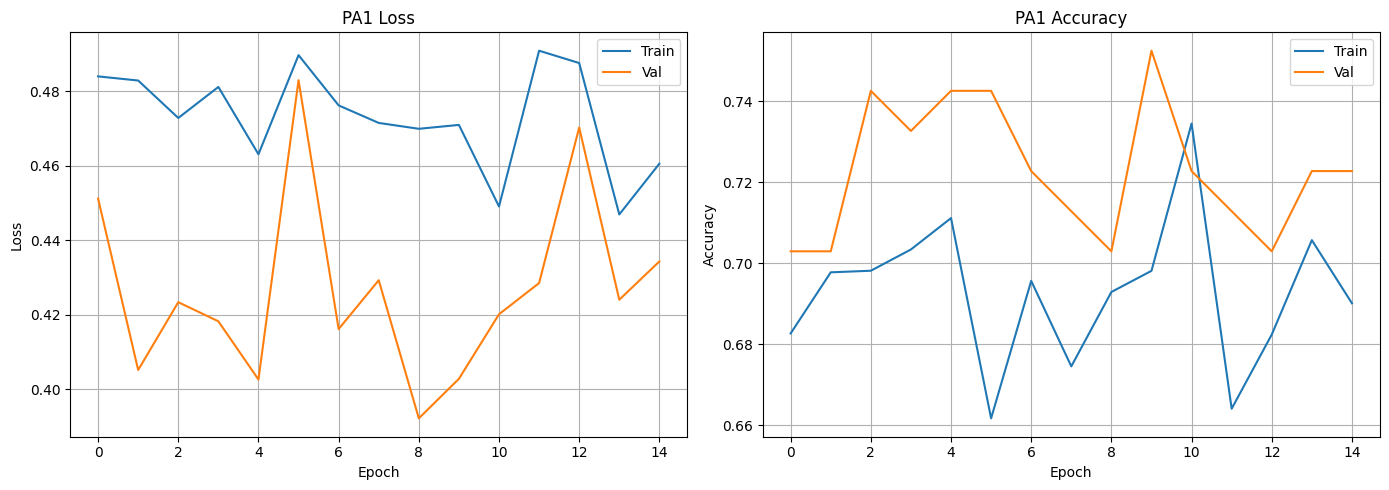

In [19]:
optimizer_pa1 = torch.optim.Adam(model_pa1.parameters(), lr=lr)#, weight_decay=weight_decay
scheduler_pa1 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa1, T_max=100, eta_min=1e-7)

best_val_loss_pa1 = float('inf')
patience_counter_pa1 = 0
train_losses_pa1, val_losses_pa1 = [], []
train_accs_pa1, val_accs_pa1 = [], []

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    current_lr = update_training_phase(model_pa1, optimizer_pa1, epoch, lr)

    model_pa1.train()
    train_correct, train_loss, train_total = 0, 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer_pa1.zero_grad()

        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args, images_fm, labels_fm)

        _, (p_tar, p_src), (y, y_shuf) = computation
        y, y_shuf = y.float(), y_shuf.float()

        outputs = model_pa1(images_fm).squeeze(1)

        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, pos_weight=pos_weight, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, pos_weight=pos_weight, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa1.parameters(), max_norm=max_norm)
        optimizer_pa1.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc
            train_loss += loss.item()
            train_total += (p_tar + p_src).sum().item()

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa1.append(train_acc)
    train_losses_pa1.append(train_loss)

    model_pa1.eval()
    val_correct, val_loss, val_total = 0, 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa1(images).squeeze(1)
            loss = criterion(outputs, labels)
            preds = (torch.sigmoid(outputs) > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_loss += loss.item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa1.append(val_acc)
    val_losses_pa1.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] PA1 Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | Time: {time.time()-epoch_start_time:.2f}s")

    scheduler_pa1.step()
    if val_loss < best_val_loss_pa1:
        best_val_loss_pa1 = val_loss
        torch.save(model_pa1.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa1.pth'))
        patience_counter_pa1 = 0
        print(f"  ✓ PA1 best model saved")
    else:
        patience_counter_pa1 += 1
        if patience_counter_pa1 >= patience:
          print(f"PA1 early stopping at epoch {epoch+1}")
          break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa1, label='Train'); ax1.plot(val_losses_pa1, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA1 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa1, label='Train'); ax2.plot(val_accs_pa1, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA1 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()


## Evaluate Model - Phương án 1

[PA1] Test Accuracy:  0.8281
[PA1] Test Precision: 0.8280
[PA1] Test Recall:    0.8281

              precision    recall  f1-score   support

         ASD       0.83      0.73      0.78        26
     non-ASD       0.83      0.89      0.86        38

    accuracy                           0.83        64
   macro avg       0.83      0.81      0.82        64
weighted avg       0.83      0.83      0.83        64



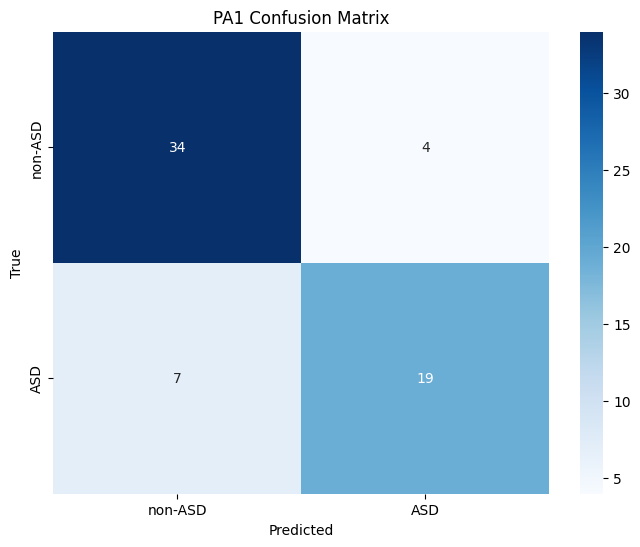

In [20]:
model_pa1.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa1.pth')))
model_pa1.eval()

y_all_pa1, yhat_all_pa1 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa1(images.to(device)))
        yhat_all_pa1.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa1.extend(labels.numpy())

y_all_pa1, yhat_all_pa1 = np.array(y_all_pa1), np.array(yhat_all_pa1)
accuracy_pa1 = (y_all_pa1 == yhat_all_pa1).mean()
precision_pa1 = precision_score(y_all_pa1, yhat_all_pa1, average='weighted')
recall_pa1 = recall_score(y_all_pa1, yhat_all_pa1, average='weighted')

print(f"[PA1] Test Accuracy:  {accuracy_pa1:.4f}")
print(f"[PA1] Test Precision: {precision_pa1:.4f}")
print(f"[PA1] Test Recall:    {recall_pa1:.4f}")
print("\n" + classification_report(y_all_pa1, yhat_all_pa1, target_names=dataset.classes))

# Confusion Matrix
conf_mat_pa1 = confusion_matrix(1 - y_all_pa1, 1 - yhat_all_pa1)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa1, annot=True, fmt='g', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA1 Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()

# Phương án 2: Thay Bottleneck bằng GhostBottleneck

Thay thế toàn bộ bottleneck layers bằng GhostBottleneck từ GhostNet paper.

## Build Model - Phương án 2

In [21]:
class GhostBottleneck(torch.nn.Module):
    def __init__(self, in_ch, out_ch, expansion=4): # Tăng expansion lên 4 để tăng sức mạnh biểu diễn
        super().__init__()
        mid_ch = in_ch * expansion
        self.ghost1 = GhostModule(in_ch, mid_ch, kernel_size=1, ratio=2)
        self.ghost2 = GhostModule(mid_ch, out_ch, kernel_size=1, ratio=2, relu=False)

    def forward(self, x):
        return self.ghost2(self.ghost1(x))

class ModelPA2(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnextv2_tiny.fcmae", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        in_features = self.backbone.num_features
        # Giảm xuống chỉ dùng 1 GhostBottleneck duy nhất thay vì stack 2 cái
        self.ghost_bottleneck = GhostBottleneck(in_features, in_features // 2, expansion=4)
        self.head = torch.nn.Linear(in_features // 2, 1)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.gap(x).flatten(1)
        x = x.unsqueeze(-1).unsqueeze(-1)
        x = self.ghost_bottleneck(x).flatten(1)
        return self.head(x)

model_pa2 = ModelPA2().to(device)
print(f"PA2 Model updated with single Bottleneck and expansion=4")

PA2 Model updated with single Bottleneck and expansion=4


## Train Model - Phương án 2

Epoch [1/100] PA2 Train Acc: 0.6045, Loss: 0.5320 | Val Acc: 0.6040, Loss: 0.5706 | Time: 7.39s
  ✓ PA2 best model saved
Epoch [2/100] PA2 Train Acc: 0.6435, Loss: 0.5063 | Val Acc: 0.6040, Loss: 0.5390 | Time: 15.92s
  ✓ PA2 best model saved
Epoch [3/100] PA2 Train Acc: 0.6484, Loss: 0.4915 | Val Acc: 0.6040, Loss: 0.5264 | Time: 7.99s
  ✓ PA2 best model saved
Epoch [4/100] PA2 Train Acc: 0.6952, Loss: 0.4669 | Val Acc: 0.6832, Loss: 0.5467 | Time: 9.08s
Epoch [5/100] PA2 Train Acc: 0.7139, Loss: 0.4589 | Val Acc: 0.7426, Loss: 0.4875 | Time: 7.44s
  ✓ PA2 best model saved
Epoch [6/100] PA2 Train Acc: 0.6982, Loss: 0.4740 | Val Acc: 0.7624, Loss: 0.4712 | Time: 16.20s
  ✓ PA2 best model saved
Epoch [7/100] PA2 Train Acc: 0.6723, Loss: 0.4825 | Val Acc: 0.7426, Loss: 0.4272 | Time: 17.88s
  ✓ PA2 best model saved
Epoch [8/100] PA2 Train Acc: 0.6489, Loss: 0.4861 | Val Acc: 0.7030, Loss: 0.4033 | Time: 16.41s
  ✓ PA2 best model saved
Epoch [9/100] PA2 Train Acc: 0.6617, Loss: 0.4726 | V

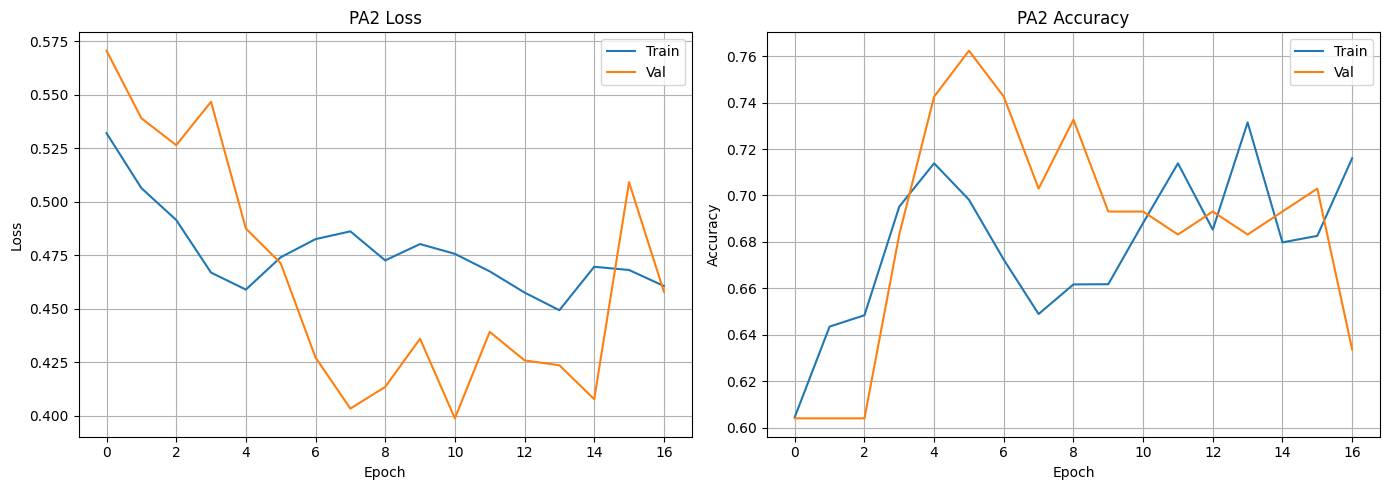

In [22]:
optimizer_pa2 = torch.optim.Adam(model_pa2.parameters(), lr=lr) #, weight_decay=weight_decay)
scheduler_pa2 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa2, T_max=100, eta_min=1e-6)

best_val_loss_pa2 = float('inf')
patience_counter_pa2 = 0
train_losses_pa2, val_losses_pa2, train_accs_pa2, val_accs_pa2 = [], [], [], []

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    current_lr = update_training_phase(model_pa2, optimizer_pa2, epoch, lr)
    model_pa2.train()
    train_correct, train_loss, train_total = 0, 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer_pa2.zero_grad()
        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args, images_fm, labels_fm)
        _, (p_tar, p_src), (y, y_shuf) = computation
        y, y_shuf = y.float(), y_shuf.float()
        outputs = model_pa2(images_fm).squeeze(1)
        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, pos_weight=pos_weight, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, pos_weight=pos_weight, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa2.parameters(), max_norm=max_norm)
        optimizer_pa2.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc
            train_loss += loss.item()
            train_total += (p_tar + p_src).sum().item()

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa2.append(train_acc)
    train_losses_pa2.append(train_loss)

    model_pa2.eval()
    val_correct, val_loss, val_total = 0, 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa2(images).squeeze(1)
            loss = criterion(outputs, labels)
            preds = (torch.sigmoid(outputs) > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_loss += loss.item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa2.append(val_acc)
    val_losses_pa2.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] PA2 Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | Time: {time.time()-epoch_start_time:.2f}s")

    scheduler_pa2.step()
    if val_loss < best_val_loss_pa2:
        best_val_loss_pa2 = val_loss
        torch.save(model_pa2.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa2.pth'))
        patience_counter_pa2 = 0
        print(f"  ✓ PA2 best model saved")
    else:
        patience_counter_pa2 += 1
        if patience_counter_pa2 >= patience:
          print(f"PA2 early stopping at epoch {epoch+1}")
          break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa2, label='Train'); ax1.plot(val_losses_pa2, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA2 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa2, label='Train'); ax2.plot(val_accs_pa2, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA2 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - Phương án 2

[PA2] Test Accuracy:  0.7812
[PA2] Test Precision: 0.7812
[PA2] Test Recall:    0.7812

              precision    recall  f1-score   support

         ASD       0.73      0.73      0.73        26
     non-ASD       0.82      0.82      0.82        38

    accuracy                           0.78        64
   macro avg       0.77      0.77      0.77        64
weighted avg       0.78      0.78      0.78        64



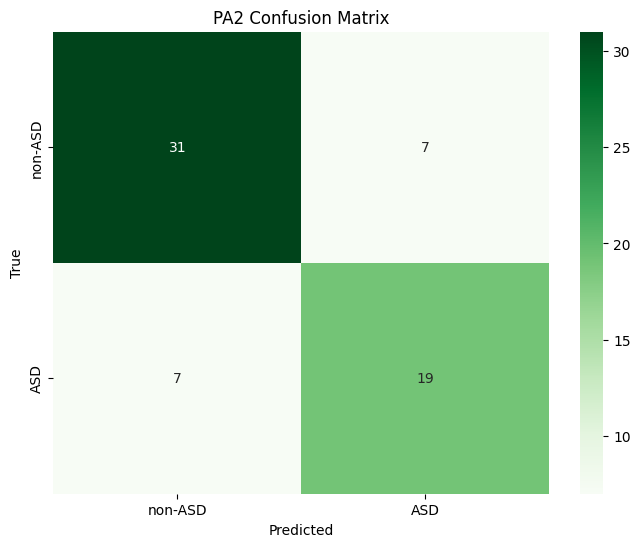

In [23]:
model_pa2.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa2.pth')))
model_pa2.eval()

y_all_pa2, yhat_all_pa2 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa2(images.to(device)))
        yhat_all_pa2.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa2.extend(labels.numpy())

y_all_pa2, yhat_all_pa2 = np.array(y_all_pa2), np.array(yhat_all_pa2)
accuracy_pa2 = (y_all_pa2 == yhat_all_pa2).mean()
precision_pa2 = precision_score(y_all_pa2, yhat_all_pa2, average='weighted')
recall_pa2 = recall_score(y_all_pa2, yhat_all_pa2, average='weighted')

print(f"[PA2] Test Accuracy:  {accuracy_pa2:.4f}")
print(f"[PA2] Test Precision: {precision_pa2:.4f}")
print(f"[PA2] Test Recall:    {recall_pa2:.4f}")
print("\n" + classification_report(y_all_pa2, yhat_all_pa2, target_names=dataset.classes))

conf_mat_pa2 = confusion_matrix(1 - y_all_pa2, 1 - yhat_all_pa2)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa2, annot=True, fmt='g', cmap='Greens', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA2 Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()

# Phương án 3: Chèn GhostModule làm Adapter

Chèn GhostModule làm adapter layer trên đường residual connection hoặc ở head để tinh chỉnh features.

## Build Model - Phương án 3

In [24]:
class GhostAdapter(torch.nn.Module):
    def __init__(self, in_channels, reduction=4):
        super().__init__()
        mid_channels = in_channels // reduction
        self.adapter = torch.nn.Sequential(
            GhostModule(in_channels, mid_channels, kernel_size=1, ratio=2),
            torch.nn.ReLU(inplace=True),
            GhostModule(mid_channels, in_channels, kernel_size=1, ratio=2, relu=False)
        )

    def forward(self, x):
        return x + self.adapter(x)

class ModelPA3(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.backbone = timm.create_model("convnextv2_tiny.fcmae", pretrained=True, num_classes=0, global_pool="")
        self.gap = torch.nn.AdaptiveAvgPool2d(1)

        in_features = self.backbone.num_features
        self.ghost_adapter = GhostAdapter(in_features, reduction=4)
        self.head = torch.nn.Linear(in_features, 1)

    def forward(self, x):
        x = self.backbone.forward_features(x)
        x = self.ghost_adapter(x)
        x = self.gap(x).flatten(1)
        return self.head(x)

model_pa3 = ModelPA3().to(device)
print(f"PA3 Model created. Features: {model_pa3.backbone.num_features}")

PA3 Model created. Features: 768


## Train Model - Phương án 3

Epoch [1/100] PA3 Train Acc: 0.5785, Loss: 0.5559 | Val Acc: 0.4455, Loss: 0.5645 | Time: 8.04s
  ✓ PA3 best model saved
Epoch [2/100] PA3 Train Acc: 0.6435, Loss: 0.5436 | Val Acc: 0.3960, Loss: 0.5582 | Time: 7.74s
  ✓ PA3 best model saved
Epoch [3/100] PA3 Train Acc: 0.6435, Loss: 0.5434 | Val Acc: 0.6139, Loss: 0.5315 | Time: 10.35s
  ✓ PA3 best model saved
Epoch [4/100] PA3 Train Acc: 0.7113, Loss: 0.5279 | Val Acc: 0.7624, Loss: 0.5262 | Time: 8.43s
  ✓ PA3 best model saved
Epoch [5/100] PA3 Train Acc: 0.6671, Loss: 0.5265 | Val Acc: 0.7723, Loss: 0.4943 | Time: 13.65s
  ✓ PA3 best model saved
Epoch [6/100] PA3 Train Acc: 0.6592, Loss: 0.5322 | Val Acc: 0.7228, Loss: 0.4795 | Time: 19.11s
  ✓ PA3 best model saved
Epoch [7/100] PA3 Train Acc: 0.6749, Loss: 0.5177 | Val Acc: 0.7030, Loss: 0.4871 | Time: 16.69s
Epoch [8/100] PA3 Train Acc: 0.6611, Loss: 0.5068 | Val Acc: 0.7822, Loss: 0.4856 | Time: 14.37s
Epoch [9/100] PA3 Train Acc: 0.6879, Loss: 0.4939 | Val Acc: 0.6337, Loss: 0.

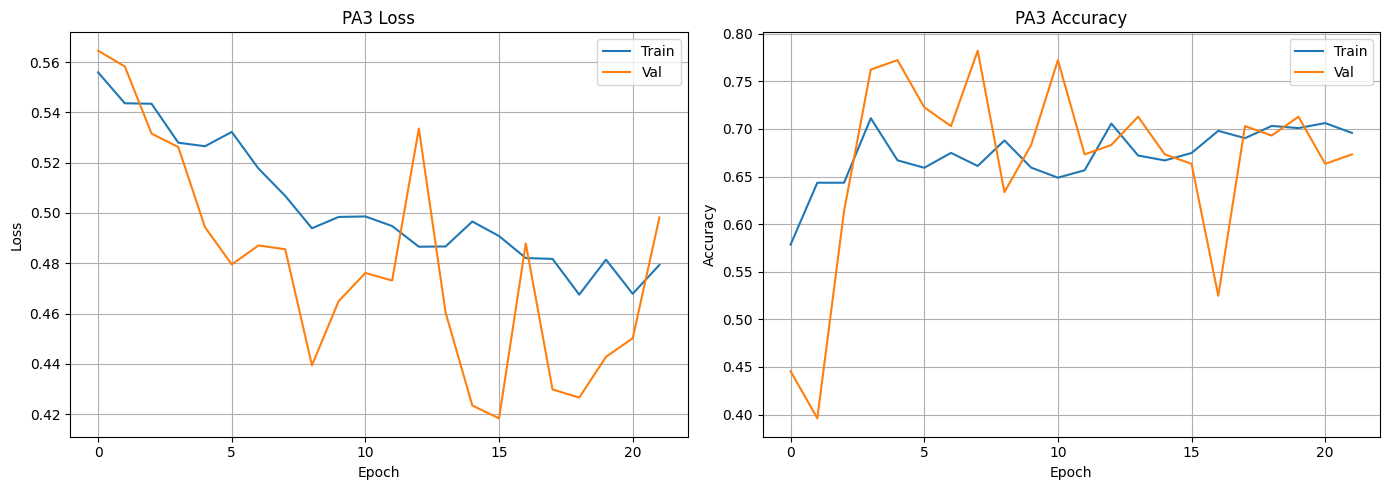

In [25]:
optimizer_pa3 = torch.optim.Adam(model_pa3.parameters(), lr=lr) #, weight_decay=weight_decay)
scheduler_pa3 = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_pa3, T_max=100, eta_min=1e-6)

best_val_loss_pa3 = float('inf')
patience_counter_pa3 = 0
train_losses_pa3, val_losses_pa3, train_accs_pa3, val_accs_pa3 = [], [], [], []

for epoch in range(num_epochs):
    epoch_start_time = time.time()
    current_lr = update_training_phase(model_pa3, optimizer_pa3, epoch, lr)
    model_pa3.train()
    train_correct, train_loss, train_total = 0, 0.0, 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device).float()
        optimizer_pa3.zero_grad()
        images_fm, labels_fm = augment_pre_fmmix1(images.clone(), labels.clone())
        images_fm, computation = fmmix1(args, images_fm, labels_fm)
        _, (p_tar, p_src), (y, y_shuf) = computation
        y, y_shuf = y.float(), y_shuf.float()
        outputs = model_pa3(images_fm).squeeze(1)
        loss_tar = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y, pos_weight=pos_weight, reduction="none")
        loss_src = torch.nn.functional.binary_cross_entropy_with_logits(outputs, y_shuf, pos_weight=pos_weight, reduction="none")
        loss = (p_tar * loss_tar + p_src * loss_src).mean()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_pa1.parameters(), max_norm=max_norm)
        optimizer_pa3.step()

        with torch.no_grad():
            preds = (outputs > 0).int()
            acc = (p_tar * (preds == y.int()).float() + p_src * (preds == y_shuf.int()).float()).sum().item()
            train_correct += acc
            train_loss += loss.item()
            train_total += (p_tar + p_src).sum().item()

    train_acc = train_correct / train_total
    train_loss /= len(train_loader)
    train_accs_pa3.append(train_acc)
    train_losses_pa3.append(train_loss)

    model_pa3.eval()
    val_correct, val_loss, val_total = 0, 0.0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device).float()
            outputs = model_pa3(images).squeeze(1)
            loss = criterion(outputs, labels)
            preds = (torch.sigmoid(outputs) > 0.5).int()
            val_correct += (preds == labels.int()).sum().item()
            val_loss += loss.item()
            val_total += labels.size(0)

    val_acc = val_correct / val_total
    val_loss /= len(val_loader)
    val_accs_pa3.append(val_acc)
    val_losses_pa3.append(val_loss)

    print(f"Epoch [{epoch+1}/{num_epochs}] PA3 Train Acc: {train_acc:.4f}, Loss: {train_loss:.4f} | Val Acc: {val_acc:.4f}, Loss: {val_loss:.4f} | Time: {time.time()-epoch_start_time:.2f}s")

    scheduler_pa3.step()
    if val_loss < best_val_loss_pa3:
        best_val_loss_pa3 = val_loss
        torch.save(model_pa3.state_dict(), os.path.join(MODEL_SAVE_PATH, 'best_pa3.pth'))
        patience_counter_pa3 = 0
        print(f"  ✓ PA3 best model saved")
    else:
        patience_counter_pa3 += 1
        if patience_counter_pa3 >= patience:
          print(f"PA3 early stopping at epoch {epoch+1}")
          break

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(train_losses_pa3, label='Train'); ax1.plot(val_losses_pa3, label='Val')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss'); ax1.set_title('PA3 Loss'); ax1.legend(); ax1.grid(True)
ax2.plot(train_accs_pa3, label='Train'); ax2.plot(val_accs_pa3, label='Val')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Accuracy'); ax2.set_title('PA3 Accuracy'); ax2.legend(); ax2.grid(True)
plt.tight_layout(); plt.show()

## Evaluate Model - Phương án 3

[PA3] Test Accuracy:  0.7812
[PA3] Test Precision: 0.7988
[PA3] Test Recall:    0.7812

              precision    recall  f1-score   support

         ASD       0.69      0.85      0.76        26
     non-ASD       0.88      0.74      0.80        38

    accuracy                           0.78        64
   macro avg       0.78      0.79      0.78        64
weighted avg       0.80      0.78      0.78        64



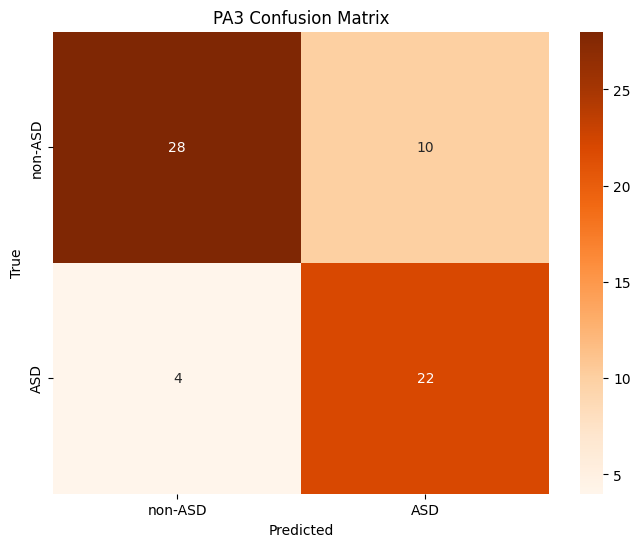

In [26]:
model_pa3.load_state_dict(torch.load(os.path.join(MODEL_SAVE_PATH, 'best_pa3.pth')))
model_pa3.eval()

y_all_pa3, yhat_all_pa3 = [], []
with torch.no_grad():
    for images, labels in test_loader:
        outputs = torch.sigmoid(model_pa3(images.to(device)))
        yhat_all_pa3.extend((outputs > 0.5).int().squeeze(1).cpu().numpy())
        y_all_pa3.extend(labels.numpy())

y_all_pa3, yhat_all_pa3 = np.array(y_all_pa3), np.array(yhat_all_pa3)
accuracy_pa3 = (y_all_pa3 == yhat_all_pa3).mean()
precision_pa3 = precision_score(y_all_pa3, yhat_all_pa3, average='weighted')
recall_pa3 = recall_score(y_all_pa3, yhat_all_pa3, average='weighted')

print(f"[PA3] Test Accuracy:  {accuracy_pa3:.4f}")
print(f"[PA3] Test Precision: {precision_pa3:.4f}")
print(f"[PA3] Test Recall:    {recall_pa3:.4f}")
print("\n" + classification_report(y_all_pa3, yhat_all_pa3, target_names=dataset.classes))

conf_mat_pa3 = confusion_matrix(1 - y_all_pa3, 1 - yhat_all_pa3)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(conf_mat_pa3, annot=True, fmt='g', cmap='Oranges', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True'); ax.set_title('PA3 Confusion Matrix')
ax.xaxis.set_ticklabels(['non-ASD', 'ASD']); ax.yaxis.set_ticklabels(['non-ASD', 'ASD'])
plt.show()